# Neural Surrogate Bayesian — Frictionless Integration Test (Consumer)

Validates the policy-based Bayesian estimation pipeline on the frictionless
basic investment model. Consumes the NN artifact bundle produced by
[`09a_neural_surrogate_pretrain.ipynb`](09a_neural_surrogate_pretrain.ipynb)
(weights, panel, metadata) and runs the EKF + NUTS inference (Bayesian.md
§3.4.1 Steps 3-4).

**Prerequisite:** run `09a_neural_surrogate_pretrain.ipynb` once to produce
the four-file bundle under `outputs/notebooks/09a_neural_surrogate_pretrain/`.
Without the bundle this notebook errors loudly.

## Pipeline detail

- **Two observation equations** at each `t`:
  1. Production:  `y_t = α log k_t + x_t + η_t`,   η ~ N(0, σ_η²)
  2. Capital LoM: `log k_{t+1} = log φ_NN(k_t, exp(x_t); β) + ξ^k_t`,   ξ ~ N(0, σ_ξ²)
- **Latent state**: `x_t = log z_t`, AR(1) transition with parameters (ρ, σ_ε).
- **Filter**: Extended Kalman Filter. At each step linearize `log φ_NN` around
  the predicted latent mean `m_{t|t-1}`. For the frictionless slice the
  analytical policy is exactly linear in log z, so a well-trained NN gives
  EKF ≡ standard Kalman with vanishing linearization error.
- **Sampler**: NUTS (via `windowed_adaptive_nuts`).
- **Estimated β** (5-dim): `(α, ρ, σ_ε, σ_η, σ_ξ)`. The posterior of `σ_ξ` is
  the inline diagnostic of NN approximation quality.

## Profiles

| Profile | Purpose | Expected MCMC wall (CPU) |
|---|---|---|
| `SMOKE` | Pipeline sanity + posterior shape | 3-8 min |
| `CALIBRATION` | Per-leapfrog runtime measurement; project FULL wall | 1-3 min |
| `FULL` | Production verification | projected from CALIBRATION |

## Reproducibility

`MASTER_SEED` is loaded from the bundle's metadata; same seed → bit-identical
panel and chain trajectory on the same hardware + TFP version.

---
# Section 0: Setup

In [1]:
# ---- Colab bootstrap (no-op when running locally) --------------------
# On Colab: clones the public repo and copies the NN bundle from Google Drive.
# Prerequisite (one-time): upload the 4 bundle files from your local
# `outputs/notebooks/09a_neural_surrogate_pretrain/` into the Drive folder
# pointed to by DRIVE_BUNDLE_DIR below. Edit that path if you put them
# elsewhere on Drive.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, shutil, subprocess

    REPO_DIR = "/content/deep-learning-corp-finance"
    REPO_URL = "https://github.com/zhaoxuanwang/deep-learning-corp-finance.git"
    REPO_BRANCH = "feat/bayesian"
    if os.path.isdir(REPO_DIR):
        # Already cloned; refresh to latest pushed commit on the branch.
        subprocess.run(["git", "-C", REPO_DIR, "fetch", "--depth=1", "origin", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", f"origin/{REPO_BRANCH}"], check=True)
        print(f"Repo refreshed to origin/{REPO_BRANCH}")
    else:
        subprocess.run(["git", "clone", "--depth=1", "--branch", REPO_BRANCH, REPO_URL, REPO_DIR], check=True)
        print(f"Repo cloned at {REPO_DIR}")

    # Mount Drive (triggers OAuth on first call per session; idempotent after).
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_BUNDLE_DIR = "/content/drive/MyDrive/dl_corp_finance/nn_bundle_09a"
    BUNDLE_DIR = os.path.join(REPO_DIR, "outputs", "notebooks", "09a_neural_surrogate_pretrain")
    os.makedirs(BUNDLE_DIR, exist_ok=True)
    bundle_files = [
        "shac_full_frictionless.meta.json",
        "shac_full_frictionless.panel.npz",
        "shac_full_frictionless.weights.h5",
        "shac_full_frictionless.weights.h5.normalizer.npz",
    ]
    missing_in_drive = [f for f in bundle_files
                         if not os.path.exists(os.path.join(DRIVE_BUNDLE_DIR, f))]
    if missing_in_drive:
        raise FileNotFoundError(
            f"NN bundle missing from Drive at {DRIVE_BUNDLE_DIR}.\n"
            f"Missing files:\n  " + "\n  ".join(missing_in_drive) + "\n"
            "Upload these from your local outputs/notebooks/09a_neural_surrogate_pretrain/ "
            "into that Drive folder, then re-run this cell.")

    copied = 0
    for f in bundle_files:
        dst = os.path.join(BUNDLE_DIR, f)
        if not os.path.exists(dst):
            shutil.copy(os.path.join(DRIVE_BUNDLE_DIR, f), dst)
            copied += 1
    print(f"NN bundle ready at {BUNDLE_DIR}/ "
          f"({copied} new copies, {len(bundle_files) - copied} already present)")

    os.chdir(REPO_DIR)
    _REPO_ROOT_OVERRIDE = REPO_DIR
    print(f"Colab bootstrap done. cwd={os.getcwd()}")
else:
    print("Local run (not Colab); bootstrap skipped.")

Repo refreshed to origin/feat/bayesian
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NN bundle ready at /content/deep-learning-corp-finance/outputs/notebooks/09a_neural_surrogate_pretrain/ (0 new copies, 4 already present)
Colab bootstrap done. cwd=/content/deep-learning-corp-finance


In [2]:
from pathlib import Path
import hashlib
import json
import os
import sys
import time
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
warnings.filterwarnings("ignore", message=r".*does not produce the same series as CPU implementation.*")
warnings.filterwarnings("ignore", message=r".*casting an input of type complex64.*")

_repo_override = globals().get("_REPO_ROOT_OVERRIDE")
if _repo_override:
    _REPO_ROOT = Path(_repo_override)
else:
    _nb_file = globals().get("__vsc_ipynb_file__")
    _REPO_ROOT = Path(_nb_file).parent.parent if _nb_file else Path.cwd().parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# CPU only by default — TF stateless RNG is bit-identical on CPU but not on
# Metal/GPU, which would violate the Bayesian.md §2.9 reproducibility claim.
USE_GPU = True

import tensorflow as tf
if not USE_GPU:
    tf.config.set_visible_devices([], "GPU")
tf.get_logger().setLevel("ERROR")

import tensorflow_probability as tfp

from src.v2.environments.basic_investment import EconomicParams, ShockParams
from src.v2.environments.parameterized_basic_investment import (
    ParameterizedBasicInvestmentEnv,
)
from src.v2.estimation import BayesianRunConfig, run_mcmc
from src.v2.estimation.bayesian_neural_basic_investment import (
    derive_env_bounds_from_panel,
    diagnose_nn_linear_slope,
    generate_frictionless_panel,
    load_policy_with_normalizer,
    make_closed_form_bayesian_spec,
    make_neural_bayesian_spec,
    neural_true_beta,
    save_policy_with_normalizer,
)
from src.v2.estimation.beta_sampler import (
    BETA_DIM_NAMES, BetaSampler, DEFAULT_UNIFORM_BOUNDS,
)
from src.v2.networks.policy import ParameterizedPolicyNetwork
from src.v2.evaluation.policies import restore_selected_snapshot
from src.v2.networks.state_value import ParameterizedStateValueNetwork
from src.v2.trainers.config import (
    SHACConfig, NetworkConfig, OptimizerConfig,
)
from src.v2.trainers.shac_param import train_shac_param
from src.v2.utils.seeding import fold_in_seed

print(f"tf: {tf.__version__}   tfp: {tfp.__version__}")
print(f"logical devices: {[d.device_type for d in tf.config.list_logical_devices()]}")
np.set_printoptions(precision=4, suppress=True)

tf: 2.19.0   tfp: 0.25.0
logical devices: ['CPU', 'GPU']


In [3]:
# ---- Load the NN artifact bundle produced by 09a_neural_surrogate_pretrain
BUNDLE_BASE = _REPO_ROOT / "outputs" / "notebooks" / "09a_neural_surrogate_pretrain" / "shac_full_frictionless"
if not BUNDLE_BASE.with_suffix(".meta.json").exists():
    raise FileNotFoundError(
        f"NN artifact bundle not found at {BUNDLE_BASE}.*. "
        "Run docs/09a_neural_surrogate_pretrain.ipynb first to produce the four bundle files "
        "(weights, normalizer, panel, metadata).")

from src.v2.environments.basic_investment import EconomicParams, ShockParams
from src.v2.environments.parameterized_basic_investment import ParameterizedBasicInvestmentEnv
from src.v2.estimation.bayesian_neural_basic_investment import (
    load_policy_with_normalizer, make_closed_form_bayesian_spec, make_neural_bayesian_spec,
)
from src.v2.estimation.beta_sampler import DEFAULT_UNIFORM_BOUNDS
from src.v2.networks.policy import ParameterizedPolicyNetwork
from src.v2.estimation import BayesianRunConfig, run_mcmc
from src.v2.utils.seeding import fold_in_seed

meta = json.loads(BUNDLE_BASE.with_suffix(".meta.json").read_text())
panel_data = np.load(BUNDLE_BASE.with_suffix(".panel.npz"))
panel_full = {"k": panel_data["k"], "z": panel_data["z"]}

# Rebuild env from metadata
nominal_econ = EconomicParams(**meta["env"]["nominal_econ"])
nominal_shocks = ShockParams(**meta["env"]["nominal_shocks"])
param_env = ParameterizedBasicInvestmentEnv(
    nominal_econ=nominal_econ, nominal_shocks=nominal_shocks,
    bounds=meta["env"]["bounds"])

# Load NN with the same architecture used in pretraining
policy_nn = ParameterizedPolicyNetwork(
    state_dim=param_env.state_dim(), action_dim=param_env.action_dim(), beta_dim=5,
    **param_env.action_spec(),
    n_layers=meta["nn_architecture"]["n_layers"],
    n_neurons=meta["nn_architecture"]["n_neurons"],
    seed=(202, 0))
policy_nn(tf.zeros((1, param_env.state_dim())), tf.zeros((1, 5)))
load_policy_with_normalizer(policy_nn, BUNDLE_BASE.with_suffix(".weights.h5"))
policy_nn.trainable = False

# Truth + master seed come from the bundle (single source of truth)
beta_true = meta["ground_truth_beta"]
MASTER_SEED = tuple(meta["master_seed"])

# Calibrated env params (also in metadata for reference)
INTEREST_RATE     = meta["env"]["interest_rate"]
DEPRECIATION_RATE = meta["env"]["depreciation_rate"]
MU                = meta["env"]["mu"]

# Extract NB09 ground-truth scalars from the dict (used in observation overlay)
TRUE_ALPHA   = float(beta_true["alpha"])
TRUE_SIG_ETA = float(beta_true["sigma_eta"])

print(f"Loaded NN bundle: cache_key={meta['cache_key']}")
print(f"  panel:           k={panel_full['k'].shape}, z={panel_full['z'].shape}")
print(f"  env bounds:      {meta['env']['bounds']}")
print(f"  best_step:       {meta['best_step']}  best_mae: {meta['best_mae']:.4f}")
print(f"  train_wall_sec:  {meta['train_wall_sec']:.1f}")
print(f"  ground-truth β:  {beta_true}")

OUTPUT_DIR = _REPO_ROOT / "outputs" / "notebooks" / "09b_neural_surrogate_bayesian"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"NB09 OUTPUT_DIR = {OUTPUT_DIR}")

Loaded NN bundle: cache_key=3a4a613afaaf
  panel:           k=(200, 41), z=(200, 41)
  env bounds:      {'k_min': 3.918094325099861, 'k_max': 45.58235660718554, 'z_min': 0.36787944117144233, 'z_max': 2.718281828459045}
  best_step:       950  best_mae: 0.4233
  train_wall_sec:  1149.6
  ground-truth β:  {'alpha': 0.5, 'rho': 0.5, 'sigma_epsilon': 0.24, 'sigma_eta': 0.05, 'sigma_xi': 0.01}
NB09 OUTPUT_DIR = /content/deep-learning-corp-finance/outputs/notebooks/09b_neural_surrogate_bayesian


---
# Section 1: Profile, observations, MCMC

Select a profile (SMOKE / CALIBRATION / FULL); slice the loaded panel to the
per-profile shape; overlay η measurement noise; build the EKF spec; run NUTS.
The CALIBRATION profile additionally projects the FULL wall time from the
measured per-leapfrog cost.

In [ ]:
MODE = "GPU_CAL"   # "SMOKE" | "CALIBRATION" | "CPU_LARGE" | "GPU_CAL" | "GPU_FULL"

# Diagnostic flag (plan: zesty-discovering-swan.md Test 1).
# When True, replaces the NN surrogate with the closed-form analytical policy
# inside the same EKF likelihood. Used to test whether identification failures
# (e.g. the GPU_CAL bias on rho/sigma_eps/sigma_eta/sigma_xi) come from the NN
# approximation or from the pipeline. Posterior with this flag should recover
# truth on all 5 params; sigma_xi posterior should concentrate near 0.
USE_CLOSED_FORM = True

# Profile design (NN training keys gone; NN comes from the pretrain bundle).
# Same target_accept_prob across profiles so per-leapfrog and tree-depth
# measurements transfer cleanly between profiles.
#
# CPU profiles (M1):
#   SMOKE         pipeline sanity + posterior shape.
#   CALIBRATION   per-leapfrog runtime measurement at small batch. Projects
#                 the CPU_LARGE wall time.
#   CPU_LARGE    production-style on CPU (long time expected, ~2-4 hours).
#
# GPU profiles (Colab T4; toggle USE_GPU=True in the setup cell):
#   GPU_CAL       T4 per-leapfrog calibration. Projects GPU_FULL wall.
#                 ~15 min wall, ~0.5 Colab units.
#   GPU_FULL      Production target: R-hat<1.01 and ESS>400 with meaningful
#                 identification at N=80, T=20. ~15h wall, ~30 Colab units.
PROFILES = {
    "SMOKE": dict(
        description="Pipeline sanity check",
        n_chains=4, n_warmup=100, n_samples=100,
        target_accept_prob=0.90,
        n_firms=10, horizon=5,
    ),
    "CALIBRATION": dict(
        description="Calibrate per-leapfrog runtime (CPU)",
        n_chains=1, n_warmup=100, n_samples=100,
        target_accept_prob=0.90,
        n_firms=10, horizon=5,
    ),
    "CPU_LARGE": dict(
        description="Production on CPU (long time expected)",
        n_chains=2, n_warmup=500, n_samples=500,
        target_accept_prob=0.90,
        n_firms=30, horizon=15,
    ),
    "GPU_CAL": dict(
        description="GPU/T4 calibration",
        n_chains=2, n_warmup=200, n_samples=200,
        target_accept_prob=0.90,
        n_firms=30, horizon=15,
    ),
    "GPU_FULL": dict(
        description="GPU/T4 production: targets R-hat<1.01 and ESS>400",
        n_chains=4, n_warmup=1000, n_samples=1000,
        target_accept_prob=0.90,
        n_firms=80, horizon=20,
    ),
}
P = PROFILES[MODE]
print(f"MODE = {MODE}: {P['description']}")

MODE = GPU_CAL: GPU/T4 calibration


---


In [5]:
if USE_CLOSED_FORM:
    spec = make_closed_form_bayesian_spec(
        param_env,
        sigma_eta_prior_scale=0.1, sigma_xi_prior_scale=0.1,
    )
    print("USING CLOSED-FORM POLICY (diagnostic regression test).")
else:
    spec = make_neural_bayesian_spec(
        param_env, policy_nn,
        sigma_eta_prior_scale=0.1, sigma_xi_prior_scale=0.1,
    )

# Tag for output filenames so closed-form runs don't clobber NN runs.
OUTPUT_TAG = f"{MODE.lower()}{'_closedform' if USE_CLOSED_FORM else ''}"
print(f"filter_kind: {spec.filter_kind.value}   sampler_kind: {spec.sampler_kind.value}")
print(f"observation_keys: {spec.observation_keys}")

# Slice the pretrain panel to the per-profile (N, T+1) shape.
# Eq 1 uses (y_t, log_k_t); Eq 2 observes log_k_{t+1}. Need T+1 raw periods
# to form T model-time observations.
N_slice = int(P["n_firms"])
T_slice = int(P["horizon"])
panel = {
    "k": panel_full["k"][:N_slice, :T_slice + 1],
    "z": panel_full["z"][:N_slice, :T_slice + 1],
}
log_k = np.log(panel["k"])             # (N, T+1)
log_z = np.log(panel["z"])             # (N, T+1)
N = log_k.shape[0]
Tp1 = log_k.shape[1]
T_eff = Tp1 - 1                         # model-time horizon
assert N == N_slice and T_eff == T_slice, \
    f"Panel slice shape mismatch: got ({N}, {Tp1}) for profile (N={N_slice}, T={T_slice})"

# η measurement noise on revenue (seeded deterministically from MASTER).
eta_seed = fold_in_seed(MASTER_SEED, "panel", "obs_noise_y")
eta = tf.random.stateless_normal(
    shape=[N, Tp1], seed=tf.constant(eta_seed, tf.int32),
    stddev=tf.constant(TRUE_SIG_ETA, tf.float32),
).numpy().astype(np.float64)
y_full = log_z + TRUE_ALPHA * log_k + eta

observed = {
    "y":          y_full[:, :T_eff,        np.newaxis].astype(np.float32),
    "log_k":      log_k[:, :T_eff,         np.newaxis].astype(np.float32),
    "log_k_next": log_k[:, 1:T_eff + 1,    np.newaxis].astype(np.float32),
}
print(f"panel slice: {N} firms x {T_eff} model-time periods")
for k, v in observed.items():
    print(f"  {k}: {v.shape}")

# Prior summary table.
prior_rows = []
for k in spec.parameter_names:
    if k in ("alpha", "rho", "sigma_epsilon"):
        lo, hi = DEFAULT_UNIFORM_BOUNDS[k]
        prior_str = f"Uniform({lo}, {hi})"
    elif k == "sigma_eta":
        prior_str = "HalfNormal(0.1)"
    elif k == "sigma_xi":
        prior_str = "HalfNormal(0.1)"
    else:
        prior_str = "?"
    prior_rows.append({"parameter": k, "true": beta_true[k], "prior": prior_str})
prior_table = pd.DataFrame(prior_rows)
display(prior_table)
prior_table.to_csv(OUTPUT_DIR / f"prior_table_{OUTPUT_TAG}.csv", index=False)

filter_kind: kalman   sampler_kind: nuts
observation_keys: ('y', 'log_k', 'log_k_next')
panel slice: 30 firms x 15 model-time periods
  y: (30, 15, 1)
  log_k: (30, 15, 1)
  log_k_next: (30, 15, 1)


,parameter,true,prior
0,alpha,0.50,"Uniform(0.2, 0.85)"
1,rho,0.50,"Uniform(0.1, 0.9)"
2,sigma_epsilon,0.24,"Uniform(0.05, 0.6)"
3,sigma_eta,0.05,HalfNormal(0.1)
4,sigma_xi,0.01,HalfNormal(0.1)


In [6]:
mcmc_seed = fold_in_seed(MASTER_SEED, "mcmc")
cfg = BayesianRunConfig(
    n_chains=P["n_chains"], n_warmup=P["n_warmup"], n_samples=P["n_samples"],
    target_accept_prob=P["target_accept_prob"],
    master_seed=tuple(MASTER_SEED),
)
print(f"Running MCMC: {cfg.n_chains} chains x ({cfg.n_warmup} warmup + {cfg.n_samples} samples), "
      f"target_accept_prob={cfg.target_accept_prob}...")
t0 = time.time()
result = run_mcmc(spec, observed, cfg, seed=tuple(mcmc_seed))
mcmc_wall_sec = time.time() - t0
print(f"MCMC wall time: {mcmc_wall_sec:.1f}s    acceptance: {result.acceptance_rate:.3f}")

# ---- Runtime calibration + projection ---------------------------------
# Per-leapfrog wall scales near-linearly with batch = n_chains * N * T above
# the hardware saturation point. Chains parallelize as a batch dim, so wall
# per iteration = mean_steps * per_leap_time(batch), NOT multiplied by n_chains.
PROJECTION_TARGETS = {
    "CALIBRATION": "CPU_LARGE",
    "GPU_CAL":     "GPU_FULL",
}
if MODE in PROJECTION_TARGETS:
    md = result.metadata
    mean_steps = md["mean_leapfrog_steps"]
    n_iter_cur = cfg.n_warmup + cfg.n_samples
    cur_batch = cfg.n_chains * N * T_eff
    ms_per_leap = 1000.0 * mcmc_wall_sec / (n_iter_cur * mean_steps)
    print()
    print("=== Runtime calibration ===")
    print(f"Per-leapfrog wall (at batch={cur_batch}): {ms_per_leap:.1f} ms")
    print(f"Mean leapfrog steps per iter: {mean_steps:.1f}  (max {md['max_leapfrog_steps']})")
    print(f"Divergences: {md['divergence_count']}")

    target_mode = PROJECTION_TARGETS[MODE]
    target = PROFILES[target_mode]
    target_batch = target["n_chains"] * target["n_firms"] * target["horizon"]
    batch_scale = target_batch / cur_batch
    target_iter = target["n_warmup"] + target["n_samples"]
    target_per_leap_ms = ms_per_leap * batch_scale     # linear batch scaling
    target_wall_s = target_iter * mean_steps * target_per_leap_ms / 1000.0
    print()
    print(f"--- Projection to {target_mode} (batch={target_batch}, {batch_scale:.0f}x current) ---")
    print(f"Projected per-leapfrog wall: {target_per_leap_ms:.1f} ms (linear batch scaling)")
    print(f"Projected {target_mode} wall: {target_wall_s/60:.1f} min ({target_wall_s/3600:.2f} hours)")
    print(f"(Tighter posterior at {target_mode} may increase mean_steps by 1.5-2x.)")

Running MCMC: 2 chains x (200 warmup + 200 samples), target_accept_prob=0.9...
MCMC wall time: 765.2s    acceptance: 0.920

=== Runtime calibration ===
Per-leapfrog wall (at batch=900): 250.6 ms
Mean leapfrog steps per iter: 7.6  (max 23)
Divergences: 0

--- Projection to GPU_FULL (batch=6400, 7x current) ---
Projected per-leapfrog wall: 1781.8 ms (linear batch scaling)
Projected GPU_FULL wall: 453.5 min (7.56 hours)
(Tighter posterior at GPU_FULL may increase mean_steps by 1.5-2x.)


---
# Section 2: Report

Posterior summary table, trace plots, marginal plots, σ_ξ diagnostic, and
pass-criteria check.

In [7]:
rows = []
for name in spec.parameter_names:
    s = result.posterior_samples[name]
    rows.append({
        "parameter": name,
        "true":      beta_true[name],
        "median":    float(np.median(s)),
        "ci_2.5":    float(np.quantile(s, 0.025)),
        "ci_97.5":   float(np.quantile(s, 0.975)),
        "r_hat":     result.r_hat[name],
        "ess":       result.ess[name],
    })
posterior_table = pd.DataFrame(rows)
print("Table 1. Posterior summary at beta_true.")
display(posterior_table)
posterior_table.to_csv(OUTPUT_DIR / f"posterior_summary_{OUTPUT_TAG}.csv", index=False)

Table 1. Posterior summary at beta_true.


,parameter,true,median,ci_2.5,ci_97.5,r_hat,ess
0,alpha,0.50,0.499821,0.496285,0.503119,1.014791,377.062561
1,rho,0.50,0.617965,0.552866,0.682444,1.022490,246.290070
2,sigma_epsilon,0.24,0.126988,0.109585,0.146862,1.009062,268.174500
3,sigma_eta,0.05,0.187728,0.171704,0.203867,0.995527,400.000000
4,sigma_xi,0.01,0.171957,0.155410,0.191510,1.000196,400.000000


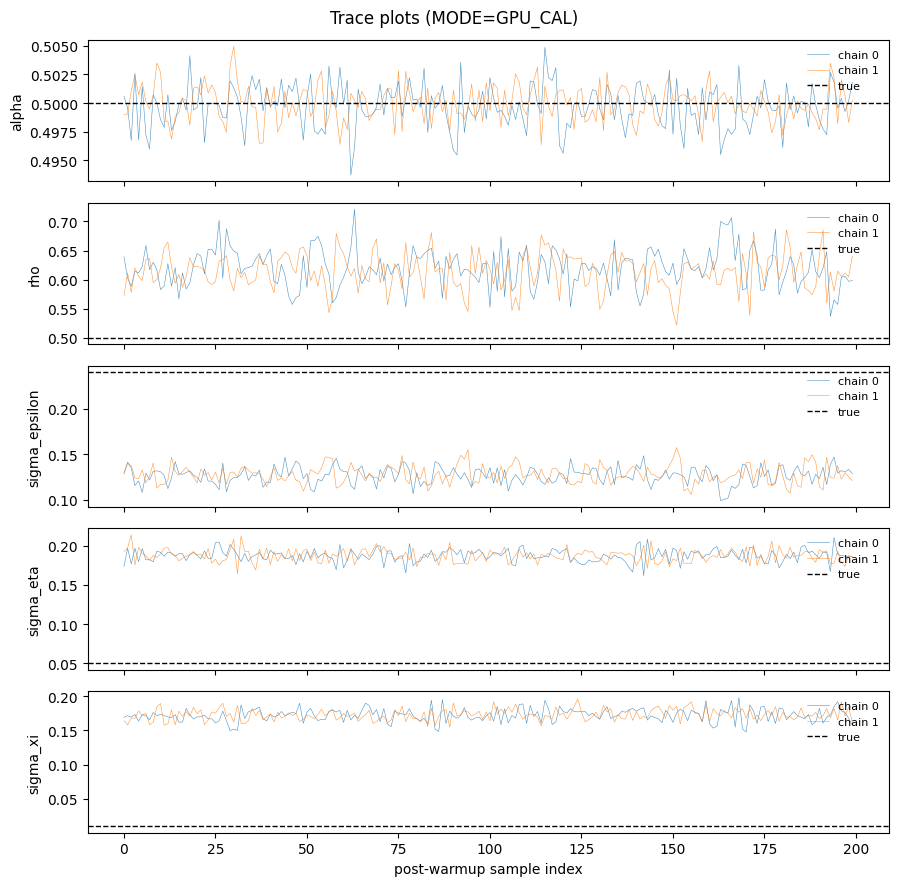

In [8]:
fig, axes = plt.subplots(len(spec.parameter_names), 1,
                          figsize=(9, 1.8 * len(spec.parameter_names)),
                          sharex=True)
for ax, name in zip(axes, spec.parameter_names):
    samples = result.posterior_samples[name]
    for c in range(samples.shape[1]):
        ax.plot(samples[:, c], lw=0.4, alpha=0.8, label=f"chain {c}")
    ax.axhline(beta_true[name], color="k", lw=1.0, ls="--", label="true")
    ax.set_ylabel(name); ax.legend(loc="upper right", fontsize=8, frameon=False)
axes[-1].set_xlabel("post-warmup sample index")
plt.suptitle(f"Trace plots (MODE={MODE})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"trace_{OUTPUT_TAG}.png", dpi=140, bbox_inches="tight")
plt.show()

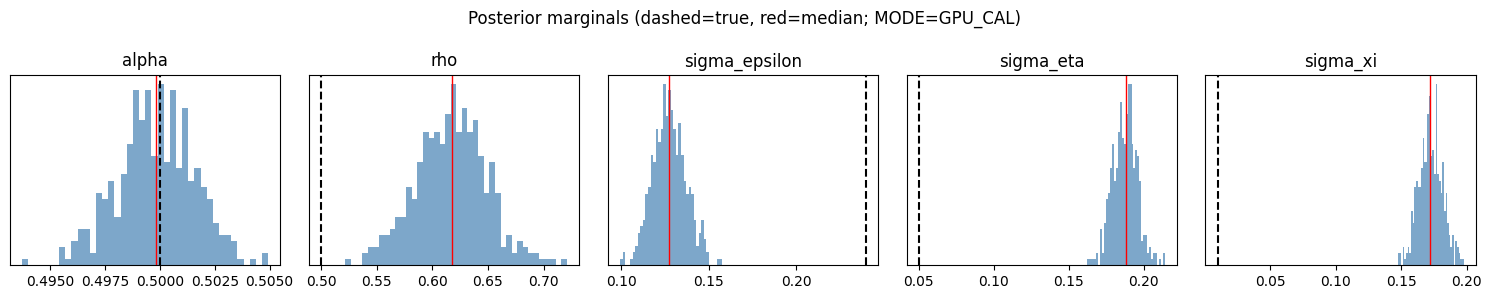

In [9]:
fig, axes = plt.subplots(1, len(spec.parameter_names),
                          figsize=(3.0 * len(spec.parameter_names), 3))
for ax, name in zip(axes, spec.parameter_names):
    samples = result.posterior_samples[name].reshape(-1)
    ax.hist(samples, bins=40, alpha=0.7, density=True, color="steelblue")
    ax.axvline(beta_true[name], color="k", lw=1.5, ls="--")
    ax.axvline(np.median(samples), color="red", lw=1.0)
    ax.set_title(name); ax.set_yticks([])
plt.suptitle(f"Posterior marginals (dashed=true, red=median; MODE={MODE})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"marginals_{OUTPUT_TAG}.png", dpi=140, bbox_inches="tight")
plt.show()

In [10]:
# Pass criteria. SMOKE thresholds are loose for the small MCMC budget.
if MODE == "SMOKE":
    R_HAT_MAX, ESS_MIN = 1.30, 100
else:
    R_HAT_MAX, ESS_MIN = 1.05, 400

print("Pass criteria check:")
print(f"  thresholds: R_hat < {R_HAT_MAX}, ESS > {ESS_MIN}")
print("-" * 70)
all_pass = True
for name in spec.parameter_names:
    s = result.posterior_samples[name].reshape(-1)
    lo, hi = float(np.quantile(s, 0.025)), float(np.quantile(s, 0.975))
    truth = beta_true[name]
    in_ci   = lo <= truth <= hi
    rhat_ok = result.r_hat[name] < R_HAT_MAX
    ess_ok  = result.ess[name] > ESS_MIN
    ok = in_ci and rhat_ok and ess_ok
    print(f"  {name:15s}: true={truth:.4f} CI=[{lo:.4f}, {hi:.4f}]  "
          f"in_CI={in_ci}  r_hat={result.r_hat[name]:.3f} ess={result.ess[name]:.0f}  "
          f"[{'OK' if ok else 'FAIL'}]")
    all_pass &= ok

sig_xi_samples = result.posterior_samples["sigma_xi"].reshape(-1)
sig_xi_p95 = float(np.quantile(sig_xi_samples, 0.95))
print(f"\nsigma_xi 95th percentile = {sig_xi_p95:.4f}")
print("  (NN approximation quality. Below ~0.05 = NN is a tight surrogate.)")

print(f"\nOVERALL: {'PASS' if all_pass else 'FAIL'}")

Pass criteria check:
  thresholds: R_hat < 1.05, ESS > 400
----------------------------------------------------------------------
  alpha          : true=0.5000 CI=[0.4963, 0.5031]  in_CI=True  r_hat=1.015 ess=377  [FAIL]
  rho            : true=0.5000 CI=[0.5529, 0.6824]  in_CI=False  r_hat=1.022 ess=246  [FAIL]
  sigma_epsilon  : true=0.2400 CI=[0.1096, 0.1469]  in_CI=False  r_hat=1.009 ess=268  [FAIL]
  sigma_eta      : true=0.0500 CI=[0.1717, 0.2039]  in_CI=False  r_hat=0.996 ess=400  [FAIL]
  sigma_xi       : true=0.0100 CI=[0.1554, 0.1915]  in_CI=False  r_hat=1.000 ess=400  [FAIL]

sigma_xi 95th percentile = 0.1872
  (NN approximation quality. Below ~0.05 = NN is a tight surrogate.)

OVERALL: FAIL


---
# Section 3: Particle filter + RW-MH (deferred)

PMMH variant of the §1.4 row-3 pipeline (the path risky-debt will need).
Out of scope for this validation. The PMMH path keeps the same `BayesianSpec`
interface; only the filter (`FilterKind.PARTICLE`) and sampler
(`SamplerKind.RW_MH`) change. The generic `run_mcmc` runner dispatches the
new pair without modification.

---
# GPU / TPU calibration recipe (Colab)

Same CALIBRATION protocol on accelerated hardware. NN training is **not**
repeated; just upload the bundle and run.

1. **Toggle the accelerator.** In cell `35c77038`, change `USE_GPU = False` to
   `True`. (The current cell only enables/disables GPU; for TPU on Colab, also
   add `tf.distribute.cluster_resolver.TPUClusterResolver(...)` setup before
   the strategy-scope code; deferred recipe.)
2. **Upload the bundle.** Copy the four files from
   `outputs/notebooks/09a_neural_surrogate_pretrain/shac_full_frictionless.*`
   into the Colab session at the same relative path (or mount Drive). The
   loader cell hard-codes the bundle path.
3. **Run CALIBRATION.** Set `MODE = "CALIBRATION"` and run the spec/observation
   and MCMC cells. The runtime-projection block prints
   `ms / leapfrog` on the new hardware.
4. **Compute speedup.** Divide CPU `ms / leapfrog` by GPU `ms / leapfrog`. A 5×
   to 30× speedup is typical for the EKF + NN forward + JVP workload on a
   single V100 / A100.
5. **Re-project FULL.** The same script re-computes the projected FULL wall
   time on GPU. Decide whether to commit to FULL on the accelerated machine
   or on CPU.

**Reproducibility caveat.** Bit-identical reruns require both the same TFP
version and the same hardware (per Bayesian.md §2.9). Switching from CPU
to GPU changes the chain trajectory; posteriors stay statistically
equivalent.